<a href="https://colab.research.google.com/github/jeetgarg2651/fright-invoice-prediction/blob/main/predicting_frieghtcost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
conn = sqlite3.connect("/content/drive/MyDrive/Jeet nptel/ML_Project/data/jet.db")
tables = pd.read_sql_query( "SELECT name from sqlite_master WHERE type='table'", conn) # sqlite_master = contain these main coloumn 1. type = table,index,view,trigger 2. name = object 2.tbl_name

In [ ]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [ ]:
for table in tables['name']:
  print("Table name",table)
  df = pd.read_sql_query(f"select * from {table} limit 5",conn)
  display(df)



Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [ ]:
#df.info()

In [ ]:
df.describe()

,Store,Brand,onHand,Price
count,5.0,5.00000,5.00000,5.000000
mean,1.0,66.00000,7.20000,27.790000
std,0.0,7.17635,2.48998,12.696456
min,1.0,58.00000,4.00000,12.990000
25%,1.0,62.00000,7.00000,14.990000
50%,1.0,63.00000,7.00000,34.990000
75%,1.0,72.00000,7.00000,36.990000
max,1.0,75.00000,11.00000,38.990000


In [ ]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head(7)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None
5,2396,BLACK PRINCE DISTILLERY INC,2024-01-08,8191,2023-12-25,2024-02-06,23,234.83,2.30,None
6,1128,BROWN-FORMAN CORP,2024-01-09,8150,2023-12-23,2024-02-19,4684,65403.57,1808.77,None


In [ ]:
vendor_df[['Quantity','Freight','Dollars']].corr() #find correlation

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


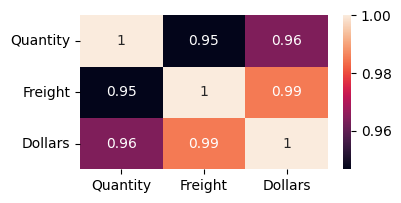

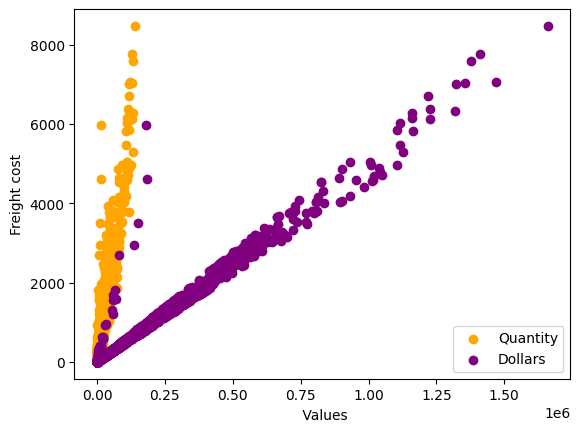

In [ ]:
#Relationship between Quantity,Dollar and freight

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Freight','Dollars']].corr(),annot = True) #“Write the numeric values inside each box of the heatmap.”
plt.show()



plt.scatter(vendor_df['Quantity'],vendor_df['Freight'], color = 'orange')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'], color = 'purple')
plt.legend(['Quantity','Dollars'])
plt.xlabel(" Values")
plt.ylabel('Freight cost')
plt.show()

frieght_per_unit because sometime bulk iteam pr cost low hoti hai kaam samn pr jada hoti hai

In [ ]:
vendor_df['frieght_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']
vendor_df




,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,frieght_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [ ]:
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,frieght_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [ ]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)



In [ ]:
low_quantity



np.float64(83.0)

In [ ]:
high_quantity

np.float64(5100.5)

In [ ]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'frieght_per_unit'].mean()# low bulk price

np.float64(0.09489854253138316)

In [ ]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'frieght_per_unit'].mean()# high bulk price

np.float64(0.049077654690759046)

In [ ]:
x = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [ ]:
vendor_df.describe().round()


,VendorNumber,PONumber,Quantity,Dollars,Freight,frieght_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#x_train
#y_test

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
model1 = LinearRegression()
model1.fit(x_train,y_train)

model2 =  DecisionTreeRegressor(random_state = 42)
model2.fit(x_train,y_train)

model3 = RandomForestRegressor(random_state = 42)
model3.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
def evalute_model(model,x_test,y_test,model_name):
  preds = model.predict(x_test)

  mae = mean_absolute_error(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  r2 = r2_score(y_test, preds)*100


  print(f"\n{model_name} performence:")
  print(f"MAE : {mae:.2f}")
  print(f"RMSE : {rmse:.2f}")
  print(f"R2 : {r2:.2f}%")

In [ ]:
evalute_model(model1,x_test,y_test,"LinearRegression")
evalute_model(model2,x_test,y_test,"DecisionTreeRegressor")# acuuracy bandne k liye max_depth use kiya hai
evalute_model(model3,x_test,y_test,"RandomForestRegressor")


LinearRegression performence:
MAE : 24.11
RMSE : 124.72
R2 : 96.99%

DecisionTreeRegressor performence:
MAE : 32.65
RMSE : 163.74
R2 : 94.81%

RandomForestRegressor performence:
MAE : 28.27
RMSE : 142.21
R2 : 96.08%


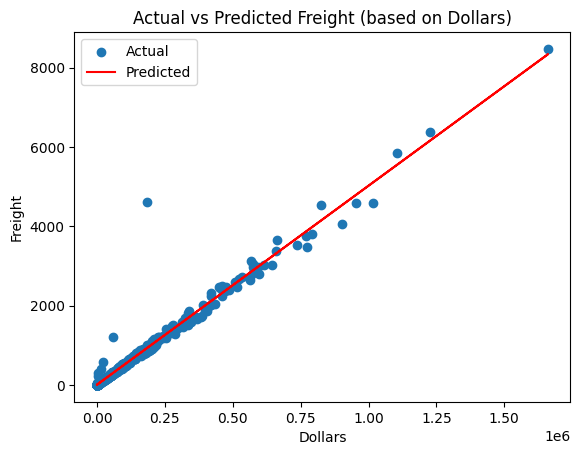

In [ ]:
plt.scatter(x_test['Dollars'],y_test)
plt.plot(x_test['Dollars'],model1.predict(x_test),color = 'red')
plt.xlabel('Dollars')
plt.ylabel('Freight')
plt.title('Actual vs Predicted Freight (based on Dollars)')
plt.legend(['Actual', 'Predicted'])
plt.show()

In [ ]:
input_data = {"Dollars":[18500,9000],}
df = pd.DataFrame(input_data)

In [ ]:
model1.predict(df)

array([97.78868161, 50.14455838])